Current Working Directory: d:\capstone_project\MYGRATE---Capstone-Project
🚀 Đang khởi chạy Mygrate Architect Agent (Strict ReAct Mode)...

🔍 Đang thu thập dữ liệu thực tế từ Maven Central...
(Bạn sẽ thấy các log [EXECUTE TOOL] hiện ra bên dưới)

-> [ARCHITECT] Deep Audit (Llama Mode): Thực hiện phân tích chuyên sâu cho dự án Java tại ...
   [STEP 1] LLM reasoning...
   [EXECUTE TOOL] find_main_build_file({'root_path': 'freshbrew_data/cantor'})
   [STEP 2] LLM reasoning...
   [EXECUTE TOOL] parse_maven_dependencies({'pom_path': 'freshbrew_data/cantor/pom.xml'})
   [STEP 3] LLM reasoning...
   [EXECUTE TOOL] list_all_versions({'artifact_id': 'junit', 'group_id': 'junit'})
   [STEP 4] LLM reasoning...
   [EXECUTE TOOL] list_all_versions({'artifact_id': 'slf4j-api', 'group_id': 'org.slf4j'})
   [STEP 5] LLM reasoning...
   [EXECUTE TOOL] list_all_versions({'artifact_id': 'hadoop-common', 'group_id': 'org.apache.hadoop'})
   [STEP 6] LLM reasoning...
   [EXECUTE TOOL] batch_check_java_compa

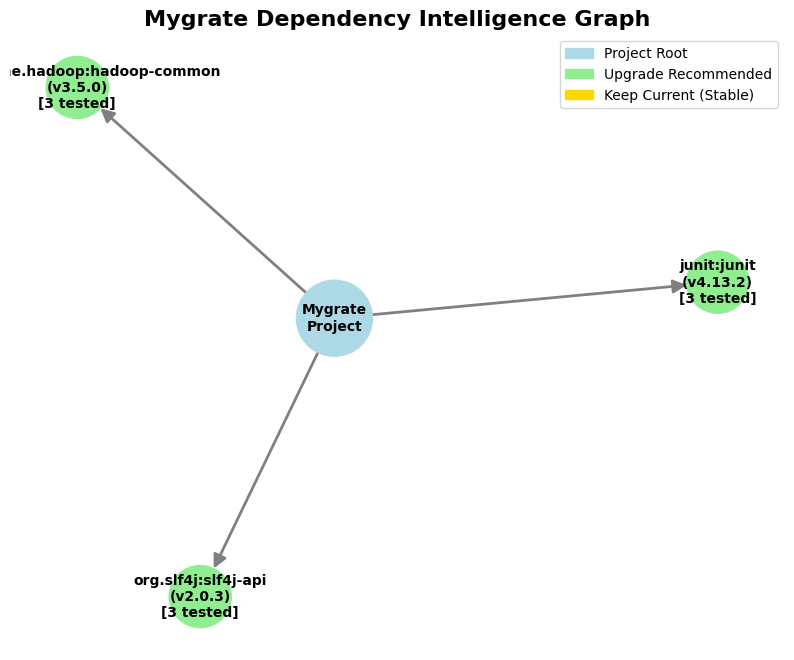


--- MA TRẬN XUNG ĐỘT (CROSS-MATRIX) ---


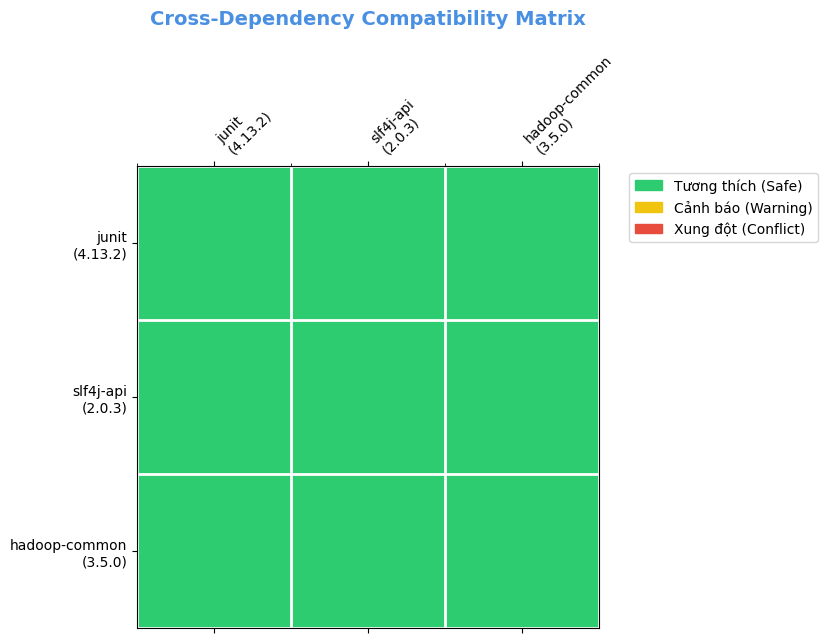

In [1]:
import os
import re
import json
import sys
from dotenv import load_dotenv
from IPython.display import Image, display

# Import Agent và Engine từ source của bạn
from src.agents.architect_agent import ArchitectAgent
from src.tools.visualization_engine import generate_dashboard, generate_cross_matrix

# Kiểm tra nếu đang ở trong thư mục notebooks thì nhảy ra ngoài
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

# Đảm bảo thư mục root nằm trong đường dẫn tìm kiếm module
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"Current Working Directory: {os.getcwd()}")


# 1. Load API Key
load_dotenv()

# 2. Khởi tạo Architect Agent (Chế độ Manual ReAct mới)
print("🚀 Đang khởi chạy Mygrate Architect Agent (Strict ReAct Mode)...")
agent = ArchitectAgent()

# 3. Gửi yêu cầu phân tích
instruction = "Thực hiện phân tích chuyên sâu cho dự án Java tại freshbrew_data/cantor để migrate lên Java 17."

print("\n🔍 Đang thu thập dữ liệu thực tế từ Maven Central...")
print("(Bạn sẽ thấy các log [EXECUTE TOOL] hiện ra bên dưới)\n")

report = agent.run(instruction)

# 4. Hiển thị báo cáo Markdown
print("\n" + "="*50)
print("📊 BẢN BÁO CÁO AUDIT CHI TIẾT")
print("="*50)
print(report)

# 5. Trích xuất JSON để vẽ đồ thị
json_match = re.search(r'```json\s*(\{.*?\})\s*```', report, re.DOTALL)
if json_match:
    json_data = json_match.group(1)
    json_path = "migration_intelligence.json"

    with open(json_path, 'w', encoding='utf-8') as f:
        f.write(json_data)

    print(f"\n[+] Đã trích xuất JSON thành công!")

    # Sinh ảnh visualization
    print("[+] Đang tạo đồ thị và ma trận tương thích...")
    generate_dashboard(json_path, "dependency_graph.png")
    generate_cross_matrix(json_path, "cross_matrix.png")

    # Hiển thị ảnh ngay trong Jupyter
    print("\n--- ĐỒ THỊ KIẾN TRÚC ---")
    display(Image(filename="dependency_graph.png"))

    print("\n--- MA TRẬN XUNG ĐỘT (CROSS-MATRIX) ---")
    display(Image(filename="cross_matrix.png"))
else:
    print("\n[-] Cảnh báo: Agent không trả về khối JSON. Vui lòng kiểm tra lại log.")
